# 2. Entity resolution, Gaia DR3 crossmatch, and mass provenance

Two independent questions this notebook answers with real data: *is this
the same star/planet across catalogues?* and *was this mass actually
measured, or predicted from the radius?* Getting either wrong silently
turns a similarity score into noise.


This notebook is part of the reproducibility set for **Finding Earth 2.0 in
Distant Worlds**. It reads the same committed data every other output in this
project reads (`results/`, `data/processed/`, `data/manifests/`) and calls
the same `earth2` functions the pipeline itself calls -- nothing here is a
simplified restatement computed a different way. Run `python -m earth2 all`
first if `results/` does not exist yet.

See `docs/METHODS.md` for the full equations and `docs/LIMITATIONS.md` for
this project's stated caveats.


In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from earth2.config import RESULTS_DIR

cat = pd.read_parquet(RESULTS_DIR / "candidate_ranking.parquet")
planets = cat[~cat["is_control"].fillna(False)]
print(f"{len(planets):,} confirmed planets in the working catalogue")


6,354 confirmed planets in the working catalogue


## Mass provenance

`classify_mass_provenance()` resolves every planet's `pl_bmassprov` string
plus its limit flag into one of six ordered evidence classes. A mass
*predicted from the radius* re-encodes the radius rather than adding
independent information -- relevant because density and escape velocity
(two of the four ESI terms) are both computed from mass and radius together.


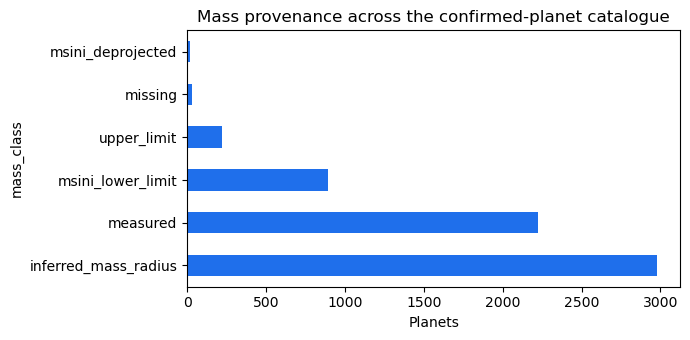

mass_class
inferred_mass_radius    2975
measured                2225
msini_lower_limit        890
upper_limit              218
missing                   31
msini_deprojected         15
Name: count, dtype: Int64

In [2]:
counts = planets["mass_class"].value_counts()
counts.plot(kind="barh", figsize=(7, 3.5), color="#1f6feb")
plt.xlabel("Planets")
plt.title("Mass provenance across the confirmed-planet catalogue")
plt.tight_layout()
plt.show()
counts


In [3]:
from earth2.preprocessing import classify_mass_provenance

example = pd.DataFrame([
    {"pl_name": "Measured example",  "pl_bmasse": 1.0, "pl_bmassprov": "Mass",             "pl_bmasselim": 0},
    {"pl_name": "Msini example",     "pl_bmasse": 1.0, "pl_bmassprov": "Msini",            "pl_bmasselim": 0},
    {"pl_name": "M-R relation example", "pl_bmasse": 1.2, "pl_bmassprov": "M-R relationship", "pl_bmasselim": 0},
    {"pl_name": "Upper-limit example", "pl_bmasse": 1.0, "pl_bmassprov": "Mass",            "pl_bmasselim": 1},
])
example["mass_class"] = classify_mass_provenance(example)
example


,pl_name,pl_bmasse,pl_bmassprov,pl_bmasselim,mass_class
0,Measured example,1.0,Mass,0,measured
1,Msini example,1.0,Msini,0,msini_lower_limit
2,M-R relation example,1.2,M-R relationship,0,inferred_mass_radius
3,Upper-limit example,1.0,Mass,1,upper_limit


## Gaia DR3 crossmatch

An **exact** `source_id` match, not a coordinate match: the NASA archive
already records a `gaia_dr3_id` string for most confirmed planets, so there
is no tolerance radius or ambiguity to reason about -- see
`src/earth2/data_sources/gaia.py`.


In [4]:
n_matched = int(planets.drop_duplicates("hostname")["gaia_source_id"].notna().sum())
n_hosts = planets["hostname"].nunique()
print(f"{n_matched:,} of {n_hosts:,} host systems ({n_matched/n_hosts:.1%}) "
      "have a Gaia DR3 crossmatch")

ruwe = pd.to_numeric(planets["gaia_ruwe"], errors="coerce")
print(f"{(ruwe > 1.4).sum()} planets have a host with RUWE > 1.4 "
      "(possible unresolved binary)")


4,408 of 4,764 host systems (92.5%) have a Gaia DR3 crossmatch
412 planets have a host with RUWE > 1.4 (possible unresolved binary)


### A real precision trap worth seeing directly

Gaia `source_id`s are up to 19 digits -- beyond a 64-bit float's exact-integer
range (2^53). A pandas column mixing a missing value with real integers is
silently promoted to float64, which **rounds** a real id. This is not
hypothetical: it happened twice while building this integration (see
`docs/RESEARCH_NOTES.md`) before both call sites were fixed to keep the id as
a string throughout.


In [5]:
import numpy as np
import pandas as pd

real_id = 2635476908753563008  # TRAPPIST-1's actual Gaia DR3 source_id
# The trap: a Series mixing None with a Python int promotes to float64.
lossy = pd.Series([real_id, None]).astype(float)
print("After an unguarded float64 promotion:", int(lossy.iloc[0]), "-- WRONG, lost precision")
print("Correct (kept as a string throughout):", str(real_id), "-- exact")


After an unguarded float64 promotion: 2635476908753563136 -- WRONG, lost precision
Correct (kept as a string throughout): 2635476908753563008 -- exact


In [6]:
from earth2.crossmatch import extract_catalogue_ids

ids = extract_catalogue_ids("TRAPPIST-1 e", [
    "Gaia DR3 2635476908753563008", "TIC 278892590", "TOI-6838", "K2-112 e",
])
ids.to_dict()


{'resolved_name': 'TRAPPIST-1 e',
 'n_aliases': 4,
 'aliases': 'Gaia DR3 2635476908753563008|TIC 278892590|TOI-6838|K2-112 e',
 'id_gaia_dr3': '2635476908753563008',
 'id_tic': '278892590',
 'id_toi': '6838'}